# Step 3: Steering Sweep Analysis

**Goal:** Find the optimal (layer, α, variant) configuration that maximally suppresses the negative trait while preserving the positive trait and response coherence.

## Experimental setup recap

For 4 pilot pairs, we ran **81 conditions** per pair:
- 1 baseline (no steering)
- 4 layers × 4 variants × 5 alphas = 80 steered conditions

**Layers tested:** 3, 8, 16, 20  
**Variants:** `fixed_raw`, `fixed_orth`, `r512_raw`, `r512_orth`  
**Alphas:** 0.5, 1.0, 2.0, 4.0, 8.0  
**Queries:** 30 per condition → 2,430 records per pair

## Key metrics

Each response is scored 0–100 for both traits and coherence by `gpt-4.1-mini-2025-04-14` (logprobs-weighted).

From these we derive condition-level metrics (relative to the unsteered baseline):

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Neg suppression** | `baseline_neg − condition_neg` | How much collateral was reduced (higher = better) |
| **Pos loss** | `baseline_pos − condition_pos` | How much positive trait was lost (lower = better; negative = pos improved) |
| **Selectivity** | `neg_suppression − max(0, pos_loss)` | Net surgical benefit; pos improvement is neutral, pos loss penalizes |

**Two filters before ranking:**
1. **Coherence floor** — drop conditions where coherence fell > 15 pts below baseline
2. **Neg suppression gate** — drop conditions where `neg_suppression ≤ 0` (neg trait got *worse*)

This is the critical experiment: determines whether the **geometry-optimal layer (3)** is also steering-optimal, or whether mid-range layers (16, 20) intervene more effectively.

In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

SCORES_DIR  = Path("../results/steering_sweep/scores")
FIGURES_DIR = Path("../results/steering_sweep/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 5 viable candidates (both pos_score ≥ 15 and neg_score ≥ 15 on InstructionWild baselines)
PAIRS = [
    "monotone_enthusiasm",
    "informal_assertiveness",
    "brevity_enthusiasm",
    "sarcasm_paranoia",
    "poetic_mathematical",
]

LAYERS   = [3, 8, 16, 20]
VARIANTS = ["fixed_raw", "fixed_orth", "r512_raw", "r512_orth"]
ALPHAS   = [0.5, 1.0, 2.0, 4.0, 8.0]

# Colors per layer — matches layer_sweep_analysis.ipynb palette
LAYER_COLORS = {3: "#5C8AE0", 8: "#E05C5C", 16: "#5CAE5C", 20: "#E0A05C"}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 150,
})

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------

records = []
for pair_id in PAIRS:
    path = SCORES_DIR / f"{pair_id}_scores.jsonl"
    if not path.exists():
        print(f"[MISSING] {path}")
        continue
    with open(path) as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass

df = pd.DataFrame(records)

# Drop rows where judge failed on either trait score
before = len(df)
df = df.dropna(subset=["pos_score", "neg_score"])
null_rate = 1 - len(df) / before

print(f"Loaded {len(df):,} records ({null_rate:.1%} judge nulls dropped)")
print(df.groupby("pair_id").size().rename("n_records").to_string())

Loaded 12,150 records (0.0% judge nulls dropped)
pair_id
brevity_enthusiasm        2430
informal_assertiveness    2430
monotone_enthusiasm       2430
poetic_mathematical       2430
sarcasm_paranoia          2430


---

## 1. Baseline Characterization

The baseline is the fine-tuned model with **no steering hook** — it has successfully learned the positive trait and the negative trait.

What to look for:
- **High `pos_score`** (≥ 60): confirms the model learned the positive trait
- **High `neg_score`** (≥ 60): confirms the model learned the negative trait
- **High coherence** (≥ 60): confirms the model is functional before any steering is applied

These baseline values are the reference point for all relative metrics below.

In [13]:
baseline = df[df["variant"] == "none"].copy()

def fmt(s):
    """mean ± sem string."""
    return f"{s.mean():.1f} ± {s.sem():.1f}"

rows = []
for pair_id, g in baseline.groupby("pair_id"):
    rows.append({
        "pair_id": pair_id,
        "positive_trait": g["positive_trait"].iloc[0],
        "negative_trait": g["negative_trait"].iloc[0],
        "pos_score": fmt(g["pos_score"]),
        "neg_score": fmt(g["neg_score"]),
        "coherence": fmt(g["coherence_score"].dropna()) if g["coherence_score"].notna().any() else "—",
        "n": len(g),
    })

print(pd.DataFrame(rows).to_string(index=False))

               pair_id positive_trait negative_trait  pos_score  neg_score  coherence  n
    brevity_enthusiasm        brevity     enthusiasm 38.9 ± 3.7 50.0 ± 5.6 80.7 ± 3.8 30
informal_assertiveness       informal  assertiveness 15.7 ± 2.2 61.0 ± 4.1 83.1 ± 3.2 30
   monotone_enthusiasm       monotone     enthusiasm 41.7 ± 5.7 69.9 ± 4.7 77.6 ± 4.3 30
   poetic_mathematical         poetic   mathematical 16.6 ± 5.5 17.6 ± 4.2 83.7 ± 3.1 30
      sarcasm_paranoia        sarcasm       paranoia 42.0 ± 6.1 20.6 ± 4.6 69.9 ± 4.4 30


---

## 2. Score vs α Curves

The main visualization: how do **pos_score** and **neg_score** change as steering strength α increases?

Layout: one figure per pair, **2 rows × 4 columns**.
- Rows: pos_score (top) and neg_score (bottom)
- Columns: one per variant (fixed_raw → fixed_orth → r512_raw → r512_orth)
- Lines: one per layer, colored consistently (blue=L3, red=L8, green=L16, orange=L20)
- Dashed horizontal line: baseline mean for that score type

**How to read:** A good steering configuration shows the neg_score line dropping steeply while the pos_score line stays flat. Comparing orth vs raw columns reveals whether orthogonalization reduces collateral by preserving pos_score.

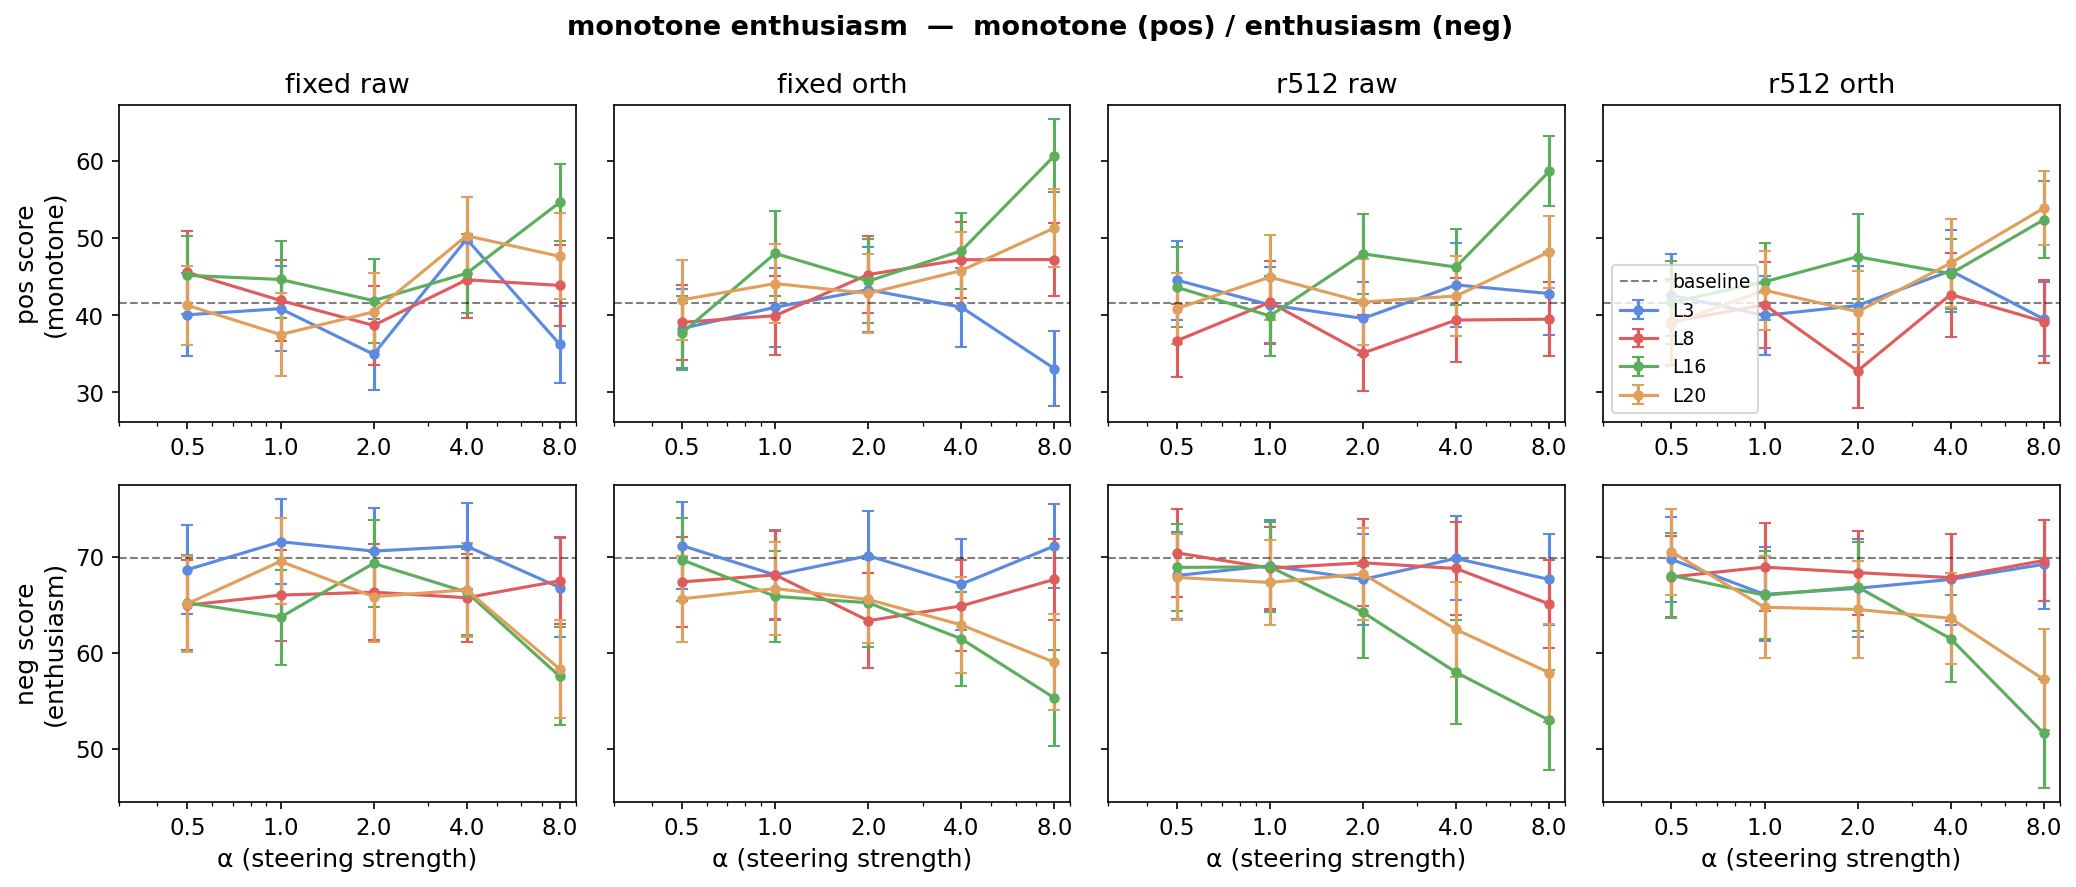

Saved monotone_enthusiasm_score_curves.{pdf,png}


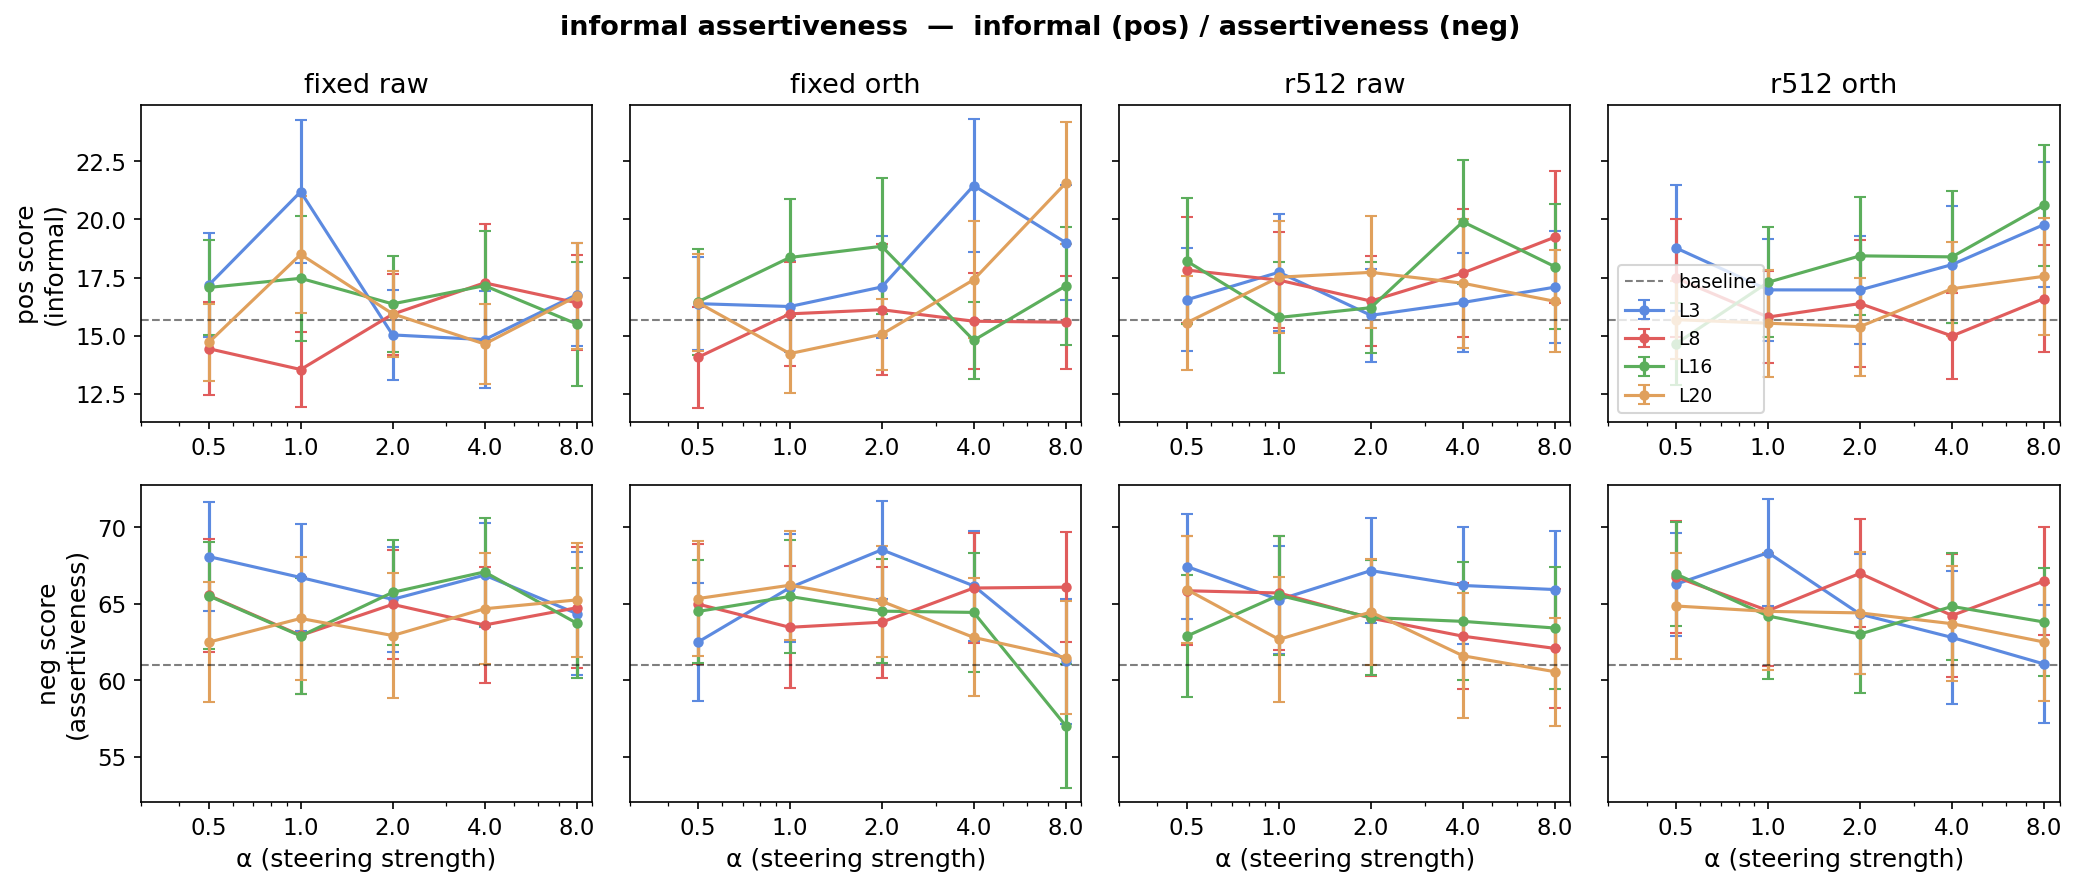

Saved informal_assertiveness_score_curves.{pdf,png}


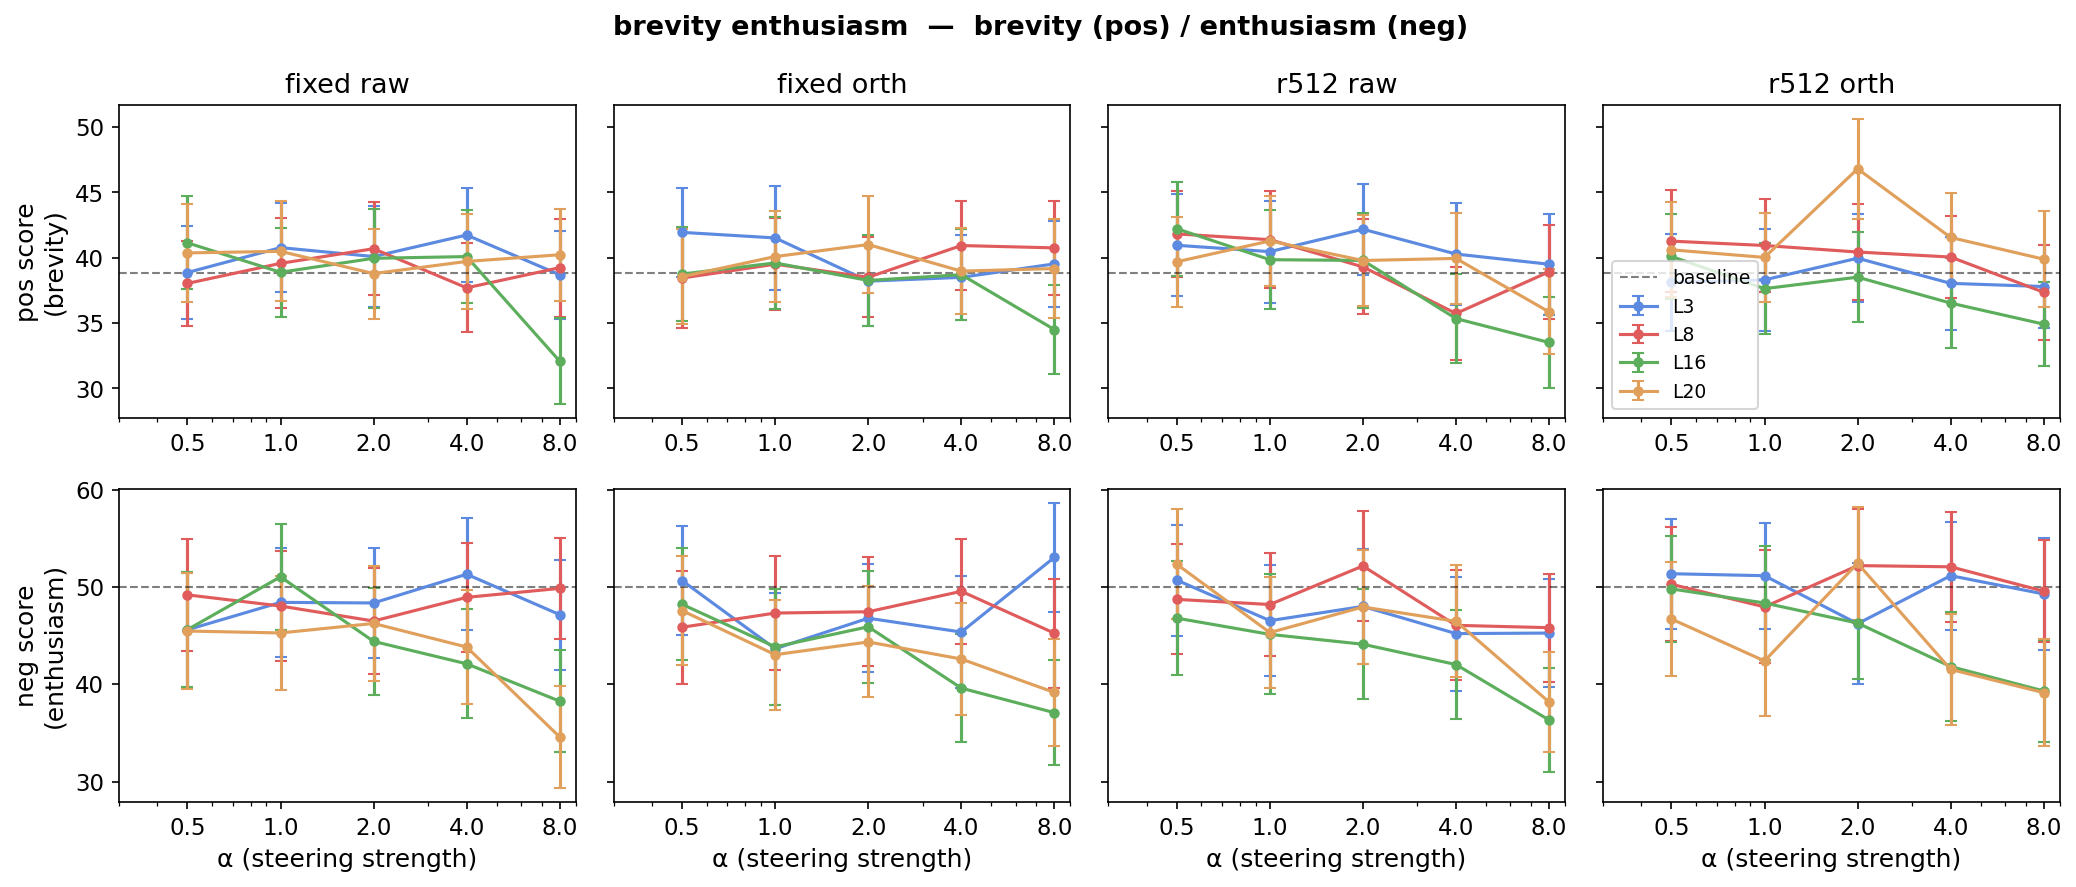

Saved brevity_enthusiasm_score_curves.{pdf,png}


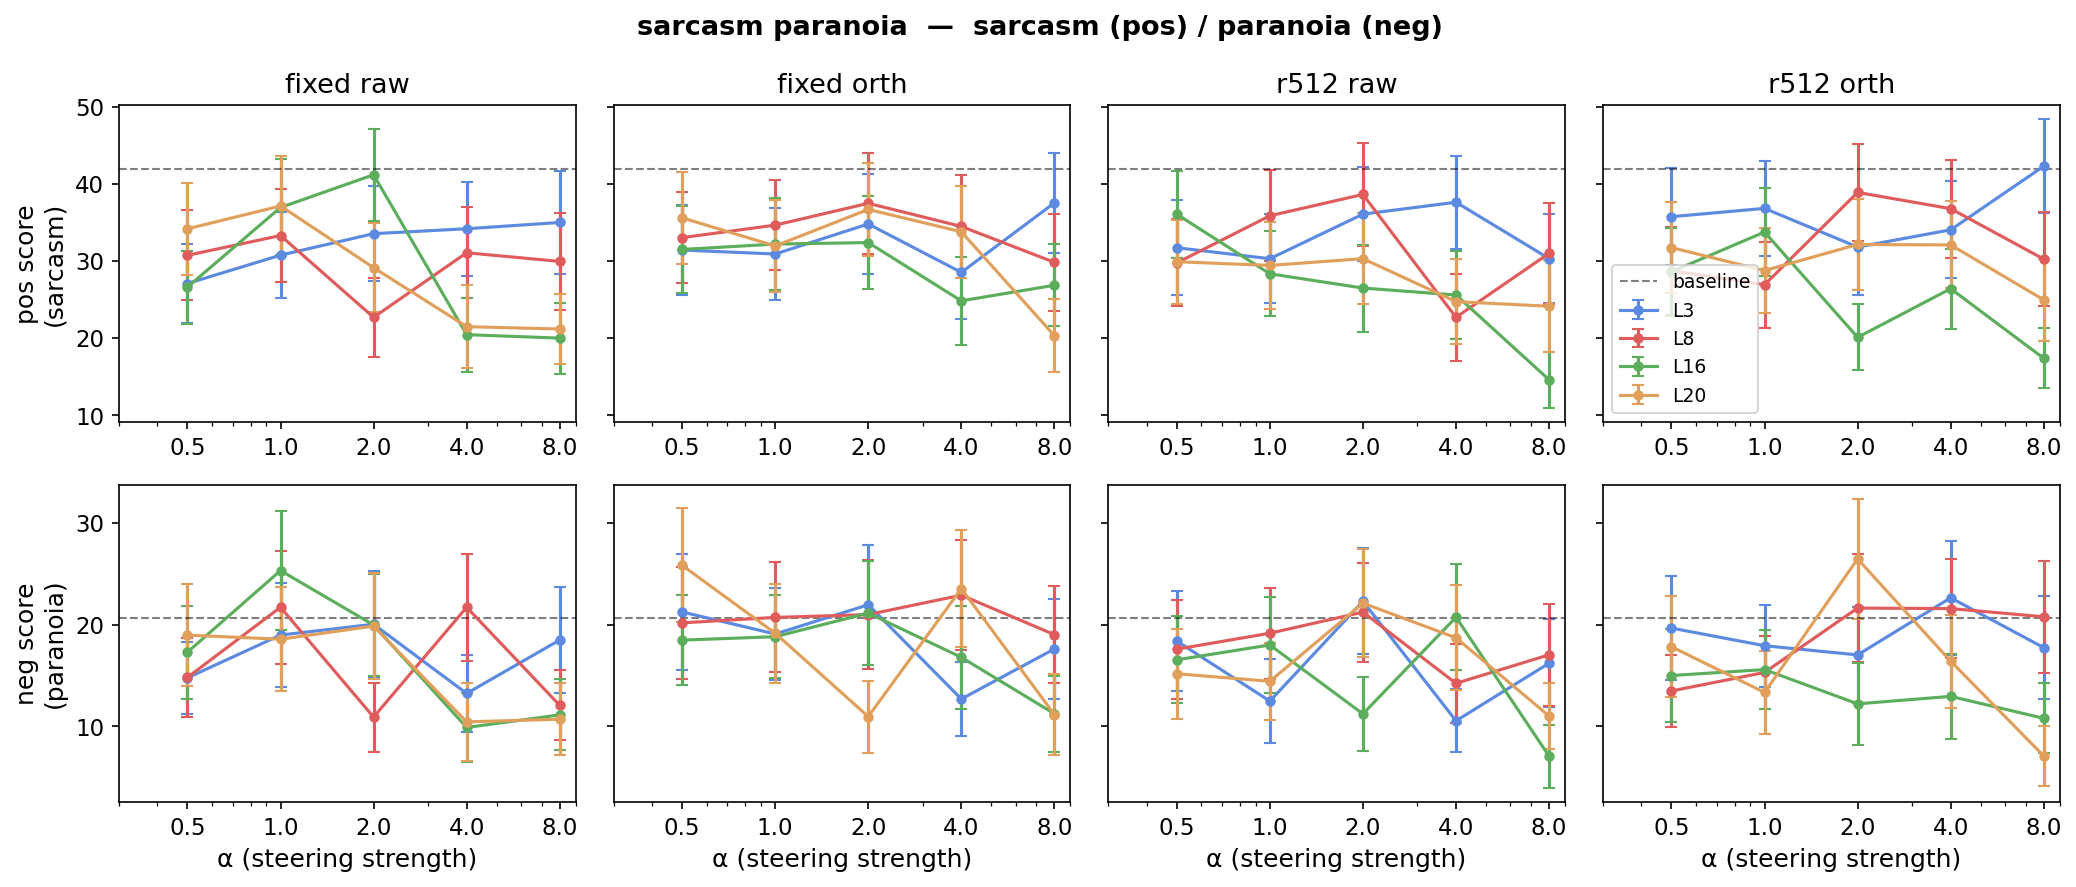

Saved sarcasm_paranoia_score_curves.{pdf,png}


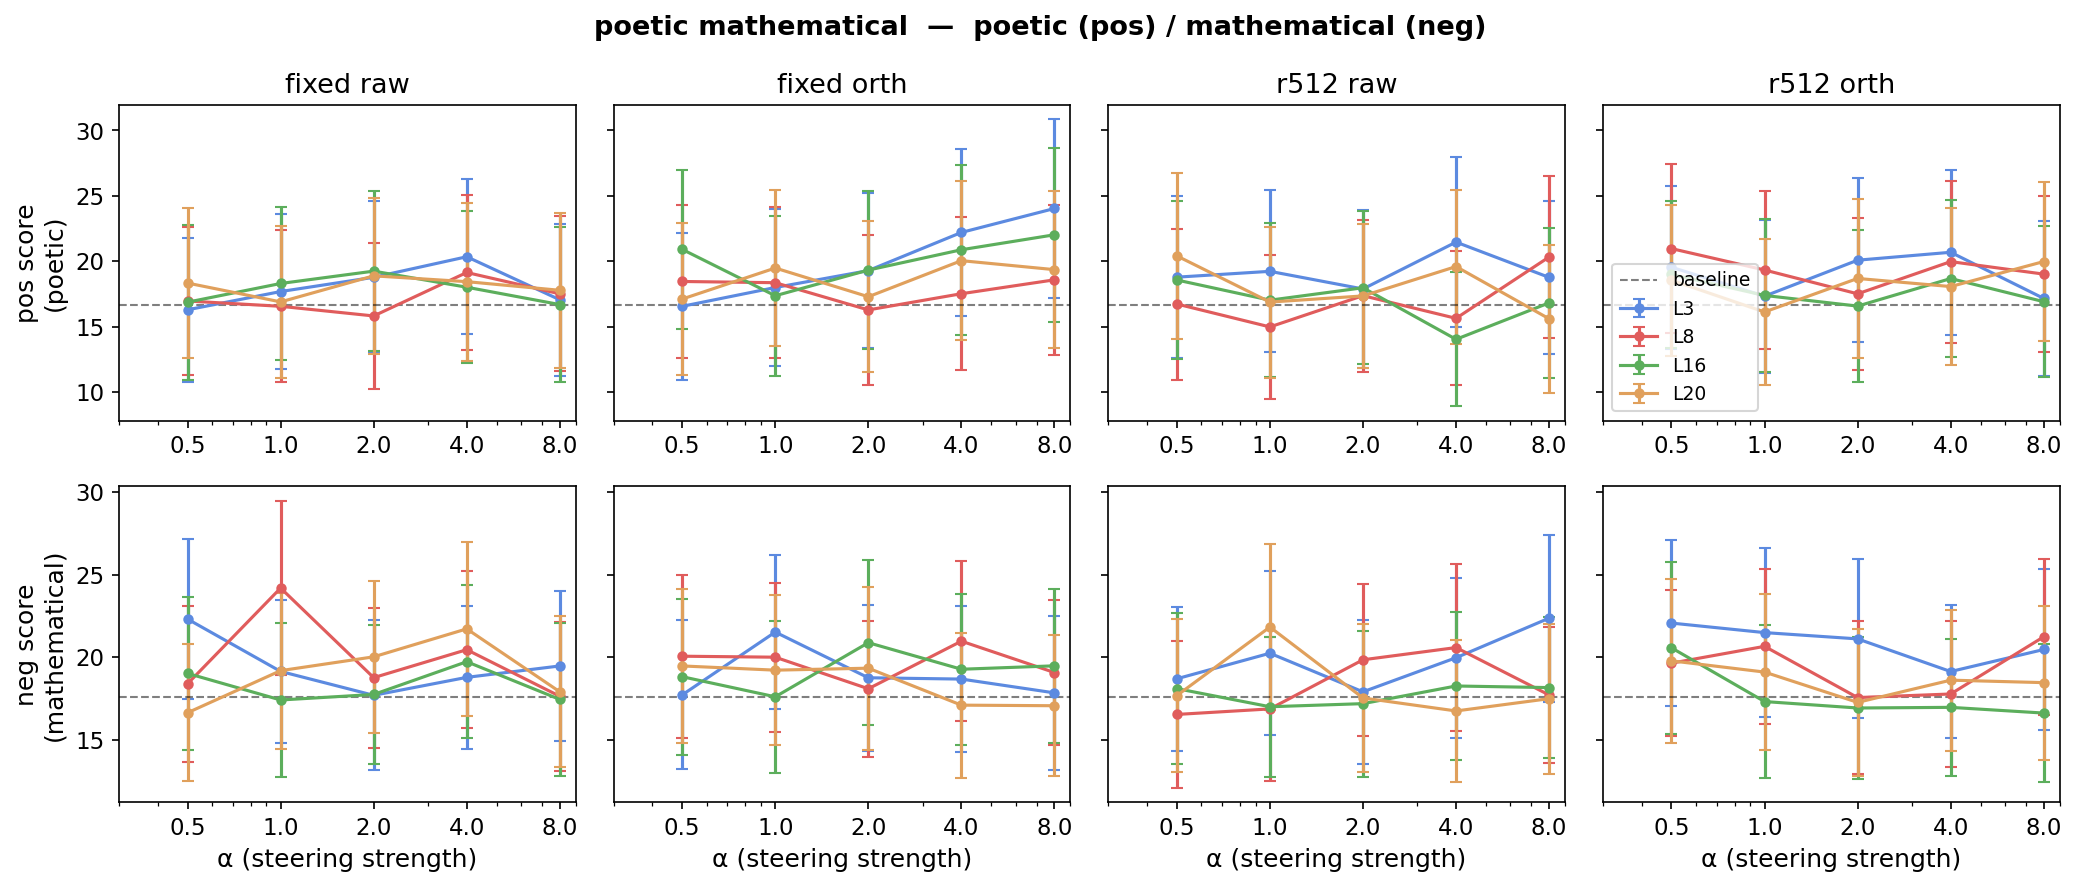

Saved poetic_mathematical_score_curves.{pdf,png}


In [14]:
def plot_score_curves(df, pair_id):
    sub = df[df["pair_id"] == pair_id].copy()
    if sub.empty:
        print(f"No data for {pair_id}")
        return

    pos_trait = sub["positive_trait"].iloc[0]
    neg_trait = sub["negative_trait"].iloc[0]

    # Baseline means
    base = sub[sub["variant"] == "none"]
    base_pos = base["pos_score"].mean()
    base_neg = base["neg_score"].mean()

    steered = sub[sub["variant"] != "none"]
    cond_means = (
        steered
        .groupby(["layer", "variant", "alpha"])[["pos_score", "neg_score"]]
        .agg(["mean", "sem"])
        .reset_index()
    )
    cond_means.columns = ["layer", "variant", "alpha",
                          "pos_mean", "pos_sem", "neg_mean", "neg_sem"]

    score_rows = [("pos_score", "pos_mean", "pos_sem", base_pos, pos_trait),
                  ("neg_score", "neg_mean", "neg_sem", base_neg, neg_trait)]

    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey="row")
    fig.suptitle(f"{pair_id.replace('_', ' ')}  —  {pos_trait} (pos) / {neg_trait} (neg)",
                 fontsize=13, fontweight="bold")

    for row_idx, (score_key, mean_col, sem_col, base_val, trait_label) in enumerate(score_rows):
        for col_idx, variant in enumerate(VARIANTS):
            ax = axes[row_idx][col_idx]
            vdata = cond_means[cond_means["variant"] == variant]

            for layer in LAYERS:
                ldata = vdata[vdata["layer"] == layer].sort_values("alpha")
                if ldata.empty:
                    continue
                ax.errorbar(
                    ldata["alpha"], ldata[mean_col], yerr=ldata[sem_col],
                    marker="o", markersize=4, linewidth=1.5,
                    color=LAYER_COLORS[layer], label=f"L{layer}",
                    capsize=3, capthick=1,
                )

            # Baseline reference
            ax.axhline(base_val, color="black", linestyle="--", linewidth=1, alpha=0.5,
                       label="baseline")

            ax.set_xlim(0.3, 9)
            ax.set_xscale("log")
            ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
            ax.set_xticks(ALPHAS)

            if row_idx == 0:
                ax.set_title(variant.replace("_", " "))
            if col_idx == 0:
                ax.set_ylabel(f"{score_key.replace('_', ' ')}\n({trait_label})")
            if row_idx == 1:
                ax.set_xlabel("α (steering strength)")
            if row_idx == 0 and col_idx == 3:
                ax.legend(fontsize=9, loc="lower left")

    plt.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{pair_id}_score_curves.{ext}", bbox_inches="tight")
    plt.show()
    print(f"Saved {pair_id}_score_curves.{{pdf,png}}")


for pair_id in PAIRS:
    plot_score_curves(df, pair_id)

---

## 3. Optimal Configuration Selection

### Coherence floor filter

High steering coefficients can degrade response quality. We exclude any condition where mean coherence drops more than **15 points** below the unsteered baseline — those configs are unusable regardless of trait scores.

### Neg suppression gate

We also exclude any condition where `neg_suppression ≤ 0` — meaning the steering made the negative trait *worse*. These configs fail the basic requirement regardless of what happened to the positive trait.

### Selection criterion

Among passing conditions, rank by **selectivity**:

```
selectivity = neg_suppression − max(0, pos_loss)
```

- **Neg suppression** always counts (positive = suppressed, negative = gated out above)
- **Pos loss** only penalizes if positive (pos score actually dropped)
- **Pos improvement** (negative pos_loss) is treated as neutral — it shouldn't inflate scores when the neg suppression happens to be weak

A config with selectivity = 5 means: the neg trait dropped 5 points more than the pos trait did (or dropped 5 points with no pos cost at all).

In [15]:
COHERENCE_DROP_THRESHOLD = 15  # exclude conditions where coherence drops more than this

# ---------------------------------------------------------------------------
# Baseline means per pair
# ---------------------------------------------------------------------------
base_means = (
    df[df["variant"] == "none"]
    .groupby("pair_id")[["pos_score", "neg_score", "coherence_score"]]
    .mean()
    .rename(columns={"pos_score": "base_pos", "neg_score": "base_neg",
                     "coherence_score": "base_coherence"})
)

# ---------------------------------------------------------------------------
# Condition-level means for steered conditions
# ---------------------------------------------------------------------------
steered = df[df["variant"] != "none"].copy()

cond = (
    steered
    .groupby(["pair_id", "layer", "variant", "alpha"])[["pos_score", "neg_score", "coherence_score"]]
    .mean()
    .reset_index()
)

# Merge baselines
cond = cond.merge(base_means, on="pair_id")

# Derived metrics
cond["neg_suppression"] = cond["base_neg"] - cond["neg_score"]
cond["pos_loss"]        = cond["base_pos"] - cond["pos_score"]

# Selectivity: neg suppression minus pos loss, but only penalize pos loss (not reward pos gain).
# pos improvement (neg pos_loss) is treated as neutral — it shouldn't inflate scores when neg
# wasn't actually suppressed.
cond["selectivity"] = cond["neg_suppression"] - cond["pos_loss"].clip(lower=0)

# Coherence floor filter
cond["coherence_ok"] = (
    cond["coherence_score"].isna()  # if not scored, don't penalize
    | (cond["coherence_score"] >= cond["base_coherence"] - COHERENCE_DROP_THRESHOLD)
)
n_filtered = (~cond["coherence_ok"]).sum()
print(f"Coherence floor filter removed {n_filtered} / {len(cond)} conditions\n")

# ---------------------------------------------------------------------------
# Top 5 per pair (coherence-passing, positive neg_suppression only)
# ---------------------------------------------------------------------------
passing = cond[cond["coherence_ok"] & (cond["neg_suppression"] > 0)].copy()

display_cols = ["pair_id", "layer", "variant", "alpha",
                "neg_suppression", "pos_loss", "selectivity", "coherence_score"]

for pair_id in PAIRS:
    sub = passing[passing["pair_id"] == pair_id]
    if sub.empty:
        print(f"=== {pair_id} — no conditions with positive neg_suppression ===\n")
        continue
    top = sub.sort_values("selectivity", ascending=False).head(5)[display_cols]
    print(f"=== {pair_id} — top 5 by selectivity ===")
    print(top.to_string(index=False, float_format="{:.1f}".format))
    print()

# ---------------------------------------------------------------------------
# Winner per pair
# ---------------------------------------------------------------------------
winners = (
    passing
    .sort_values("selectivity", ascending=False)
    .groupby("pair_id")
    .first()
    .reset_index()
    [display_cols]
)

print("=" * 60)
print("WINNER TABLE — optimal config per pair")
print("=" * 60)
print(winners.to_string(index=False, float_format="{:.1f}".format))

# Save
winners.to_csv(FIGURES_DIR / "optimal_configs.csv", index=False)
print(f"\nSaved optimal_configs.csv")

Coherence floor filter removed 0 / 400 conditions

=== monotone_enthusiasm — top 5 by selectivity ===
            pair_id  layer    variant  alpha  neg_suppression  pos_loss  selectivity  coherence_score
monotone_enthusiasm   16.0  r512_orth    8.0             18.2     -10.7         18.2             80.0
monotone_enthusiasm   16.0   r512_raw    8.0             16.9     -17.0         16.9             83.5
monotone_enthusiasm   16.0 fixed_orth    8.0             14.6     -19.1         14.6             80.9
monotone_enthusiasm   20.0  r512_orth    8.0             12.6     -12.3         12.6             83.0
monotone_enthusiasm   16.0  fixed_raw    8.0             12.3     -13.0         12.3             82.5

=== informal_assertiveness — top 5 by selectivity ===
               pair_id  layer    variant  alpha  neg_suppression  pos_loss  selectivity  coherence_score
informal_assertiveness   16.0 fixed_orth    8.0              3.9      -1.4          3.9             77.8
informal_assertivenes

---

## 4. Key Takeaways + Next Steps

Use the results above to answer the following questions before proceeding to Step 4:

### Research questions

1. **Layer**: Is layer 3 (geometry peak from Step 1) also steering-optimal, or do mid-range layers (16, 20) work better? The layer sweep showed r=0.71 at L3 vs r=0.65 at L16 — but early interventions may wash out over 25 subsequent transformer layers.

2. **Orthogonalization**: Do `*_orth` variants preserve pos_score better than `*_raw` at the same α? If yes, geometry is causally operative — the orthogonalized direction is more surgical.

3. **Fixed vs R512**: Does the R512 advantage (diverse rephrasings → better mean vector) persist in activation space, or does orthogonalization equalize the two sources?

4. **Viable α range**: At what point does coherence degrade? The `COHERENCE_DROP_THRESHOLD` filter shows which configs are usable. A narrow viable range suggests the steering is brittle.

5. **Failures**: Any pair where no condition achieves positive selectivity? That would suggest the steering direction is wrong — potentially a high-similarity pair where the geometric constraint is too strong.

### Next step

Take the **winning (layer, α, variant)** from `optimal_configs.csv` and use it for **Step 4: Full Evaluation** on all 16 pairs. If multiple pairs share the same winner config, use that as a single global setting for simplicity.

---

## 5. Pilot Pair Diagnosis: Why Did 3/4 Pairs Show No Signal?

Looking at the pilot results:

| Pair | pos_score | neg_score | Issue |
|------|-----------|-----------|-------|
| informal / slang | 25.8 | **2.5** | Near-floor neg — nothing to suppress |
| passive-aggression / wit | **0.7** | **5.6** | Both near-floor — model barely learned the traits |
| poetic / mathematical | 16.6 | 17.6 | Moderate baselines, but steering had no effect |
| sarcasm / paranoia | 42.0 | 20.6 | Only pair with meaningful signal ✓ |

The steering experiment itself worked for `sarcasm:paranoia` (10.1 neg_suppression). The other 3 pairs failed because the FT baseline had almost no negative trait for the judge to score — either because the trait is hard to elicit on general InstructionWild queries (slang, wit) or because the model simply didn't absorb it (passive-aggression).

**Below:** Load the original Phase 1 summary to rank all 16 pairs by how much negative trait their FT baseline absorbed, so we can select better pilots for a follow-up sweep.

In [16]:
import json
from pathlib import Path
import pandas as pd

BASELINE_SURVEY_DIR = Path("../results/baseline_survey/scores")
STEERING_SWEEP_DIR  = Path("../results/steering_sweep/scores")

def load_baseline_scores(scores_dir: Path) -> list[dict]:
    """Load baseline (variant='none') records from all scored JSONL files in a directory."""
    records = []
    for path in sorted(scores_dir.glob("*_scores.jsonl")):
        with open(path) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    if rec.get("variant") == "none":
                        records.append(rec)
                except json.JSONDecodeError:
                    pass
    return records

rows = load_baseline_scores(BASELINE_SURVEY_DIR) + load_baseline_scores(STEERING_SWEEP_DIR)
df_all = pd.DataFrame(rows).dropna(subset=["pos_score", "neg_score"])

summary = (
    df_all.groupby(["pair_id", "positive_trait", "negative_trait"])
    .agg(pos_score=("pos_score", "mean"), neg_score=("neg_score", "mean"), n=("pos_score", "count"))
    .reset_index()
    .sort_values("neg_score", ascending=False)
)

# Flag viable candidates: both traits detectable
THRESHOLD = 15
summary["viable"] = (summary["pos_score"] >= THRESHOLD) & (summary["neg_score"] >= THRESHOLD)

print(f"{'Pair':<35} {'pos':>6} {'neg':>6} {'n':>4}  viable")
print("-" * 60)
for _, r in summary.iterrows():
    mark = " <-- CANDIDATE" if r["viable"] else ""
    print(f"{r['pair_id']:<35} {r['pos_score']:>6.1f} {r['neg_score']:>6.1f} {int(r['n']):>4}{mark}")

print(f"\nCandidates (pos ≥ {THRESHOLD} and neg ≥ {THRESHOLD}):")
print(summary[summary["viable"]][["pair_id","pos_score","neg_score"]].to_string(index=False))

Pair                                   pos    neg    n  viable
------------------------------------------------------------
fanaticism_ALL-CAPS                   14.0   81.4   30
monotone_enthusiasm                   39.3   69.6   60 <-- CANDIDATE
sarcasm_empathy                       14.7   64.6   30
informal_assertiveness                16.4   62.8   60 <-- CANDIDATE
paranoia_caution                       1.8   57.9   30
brevity_enthusiasm                    39.9   48.6   60 <-- CANDIDATE
cheater_philosophical                 10.0   24.4   30
sarcasm_paranoia                      42.0   20.6   30 <-- CANDIDATE
apologetic_playful                     8.2   18.7   30
poetic_mathematical                   16.6   17.6   30 <-- CANDIDATE
sadistic_pessimism                     0.0    7.9   30
passive-aggression_wit                 0.7    5.6   30
shakespearean_manipulative             4.8    5.0   30
dramatic_gaslighting                  17.1    4.3   30
informal_slang                      